### B3. Python Packages & Libraries

In [1]:
# Import the python packages & libraries 
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Read In Dataset

In [2]:
# Utilize the Pandas library to create a dataframe (df) to visualize our data at a high level
df = pd.read_csv('medical_clean.csv')

# Preview the dataframe (displaying all columns)
pd.set_option("display.max_columns", None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [3]:
# Review dataset column data types, value counts and total rows/columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

### C3. Data Preparation Steps

#### Step 1. Detect & Handle Missing Values

In [4]:
# Check for missing values in our dataset
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

#### Step 2. Outlier Detection & Handling

In [5]:
# Summary statistics for continuous variables to check for outliers
continuous_summary = df[['Age', 'Income', 'VitD_levels', 'Doc_visits', 'Initial_days', 'Full_meals_eaten', 'TotalCharge', 'Additional_charges']].describe()
continuous_summary

,Age,Income,VitD_levels,Doc_visits,Initial_days,Full_meals_eaten,TotalCharge,Additional_charges
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.511700,40490.495160,17.964262,5.012200,34.455299,1.001400,5312.172769,12934.528587
std,20.638538,28521.153293,2.017231,1.045734,26.309341,1.008117,2180.393838,6542.601544
min,18.000000,154.080000,9.806483,1.000000,1.001981,0.000000,1938.312067,3125.703000
25%,36.000000,19598.775000,16.626439,4.000000,7.896215,0.000000,3179.374015,7986.487755
50%,53.000000,33768.420000,17.951122,5.000000,35.836244,1.000000,5213.952000,11573.977735
75%,71.000000,54296.402500,19.347963,6.000000,61.161020,2.000000,7459.699750,15626.490000
max,89.000000,207249.100000,26.394449,9.000000,71.981490,7.000000,9180.728000,30566.070000


In [6]:
# Check for outliers in our Income data by looking at the largest and smallest values
income_largest = df['Income'].nlargest(30)
income_smallest = df['Income'].nsmallest(30)

print("LOWEST PATIENT INCOMES (Low to High):\n", income_smallest.to_string(index=False))
print("\nHIGHEST PATIENT INCOMES (High to Low):\n", income_largest.to_string(index=False))

LOWEST PATIENT INCOMES (Low to High):
  154.08
 300.79
 395.23
 401.86
 493.04
 695.22
 702.16
 798.98
 826.01
 881.07
 881.40
 953.74
1048.43
1078.12
1196.72
1209.56
1277.08
1286.25
1301.34
1366.98
1380.70
1392.23
1402.22
1409.92
1453.90
1480.67
1482.85
1486.44
1528.80
1541.63

HIGHEST PATIENT INCOMES (High to Low):
 207249.10
204542.41
203774.60
197675.00
197576.18
196915.60
194796.24
190110.80
189416.27
189129.92
186791.40
186752.00
183037.10
179543.70
178945.40
178470.63
174745.85
171680.20
171288.05
171031.20
170961.50
167286.62
167105.10
166702.70
166048.50
166017.39
165588.50
165560.97
165329.55
164123.69


#### Step 3. Check & Fix Data Types

In [7]:
# Check data types of variables
df.dtypes

CaseOrder               int64
Customer_id            object
Interaction            object
UID                    object
City                   object
State                  object
County                 object
Zip                     int64
Lat                   float64
Lng                   float64
Population              int64
Area                   object
TimeZone               object
Job                    object
Children                int64
Age                     int64
Income                float64
Marital                object
Gender                 object
ReAdmis                object
VitD_levels           float64
Doc_visits              int64
Full_meals_eaten        int64
vitD_supp               int64
Soft_drink             object
Initial_admin          object
HighBlood              object
Stroke                 object
Complication_risk      object
Overweight             object
Arthritis              object
Diabetes               object
Hyperlipidemia         object
BackPain  

In [8]:
# Cast Income column data type from float to integer
df["Income"] = df["Income"].astype(int)

In [9]:
# Reduce column precision down to 2 decimal places to better reflect USD pricing and improve readability
df["TotalCharge"] = df.TotalCharge.round(2)
df["Additional_charges"] = df.TotalCharge.round(2)
df["VitD_levels"] = df.VitD_levels.round(2)

#### Step 4. Subset the Dataset

In [10]:
# Subset the dataset, selecting only the columns relevant to our research question
relevant_columns = [
    "Age",
    "Income",
    "VitD_levels",
    "Doc_visits",
    "Initial_days",
    "Full_meals_eaten", 
    "TotalCharge",
    "Additional_charges"
]

df_subset = df[relevant_columns]

# Preview the resulting dataframe
df_subset

,Age,Income,VitD_levels,Doc_visits,Initial_days,Full_meals_eaten,TotalCharge,Additional_charges
0,53,86575,19.14,6,10.585770,0,3726.70,3726.70
1,51,46805,18.94,4,15.129562,2,4193.19,4193.19
2,53,14370,18.06,4,4.772177,1,2434.23,2434.23
3,78,39741,16.58,4,1.714879,1,2127.83,2127.83
4,22,1209,17.44,5,1.254807,0,2113.07,2113.07
...,...,...,...,...,...,...,...,...
9995,25,45967,16.98,4,51.561220,2,6850.94,6850.94
9996,87,14983,18.18,5,68.668240,0,7741.69,7741.69
9997,45,65917,17.13,4,70.154180,2,8276.48,8276.48
9998,43,29702,19.91,5,63.356900,2,7644.48,7644.48


#### Step 5. Update Column Names

In [11]:
# Update column labels for better understanding and consistency
updated_columns = [
    "age",
    "income",
    "vitamin_d_level",
    "doctor_visits",
    "inital_days",
    "full_meals_eaten",
    "total_charges",
    "additional_charges"
]

df_subset = df_subset.set_axis(updated_columns, axis=1)

# Preview the resulting dataframe
df_subset

,age,income,vitamin_d_level,doctor_visits,inital_days,full_meals_eaten,total_charges,additional_charges
0,53,86575,19.14,6,10.585770,0,3726.70,3726.70
1,51,46805,18.94,4,15.129562,2,4193.19,4193.19
2,53,14370,18.06,4,4.772177,1,2434.23,2434.23
3,78,39741,16.58,4,1.714879,1,2127.83,2127.83
4,22,1209,17.44,5,1.254807,0,2113.07,2113.07
...,...,...,...,...,...,...,...,...
9995,25,45967,16.98,4,51.561220,2,6850.94,6850.94
9996,87,14983,18.18,5,68.668240,0,7741.69,7741.69
9997,45,65917,17.13,4,70.154180,2,8276.48,8276.48
9998,43,29702,19.91,5,63.356900,2,7644.48,7644.48


#### Step 6. Standardize the Dataset for K-Means Clustering

In [12]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_data = scaler.fit_transform(df_subset)

### C4. Cleaned Dataset

In [13]:
# Save the transformed dataset as a CSV file
df_subset.to_csv('d212_task1_transformed_medical_clean.csv', index=False)

print(f"The final cleaned and scaled dataset has been saved as:\n 'd212_task1_transformed_medical_clean.csv'")

The final cleaned and scaled dataset has been saved as:
 'd212_task1_transformed_medical_clean.csv'


### D2. Code to Perform Clustering Analysis

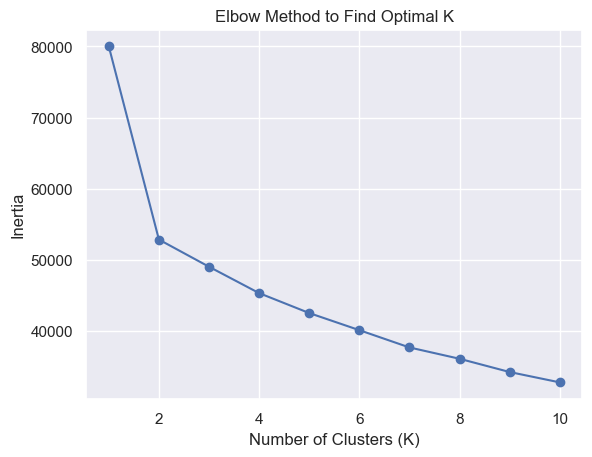

In [14]:
# Finding Optimal K

# Create an empty list to store the inertia value for each value of K
inertia = []

# Define range of cluster numbers (K) to test, starting with 1 to 10 clusters
k_range = range(1, 11)

for k in k_range:
    # Create a KMeans model for the current value of k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit the Kmeans model on the scaled dataset
    kmeans.fit(scaled_data)
    # Add inertia value from the fitted model to the inertia list
    inertia.append(kmeans.inertia_)

# Plot a line chart of K values vs. inertia 
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Find Optimal K')
plt.show()

In [15]:
# Using the optimal number of clusters to perform the cluster analysis

# Define optimal k
optimal_k = 3

# Intialize KMeans model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit Kmeans model to standardized dataset
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to the original dataset
df_subset['Cluster'] = clusters

# Cluster summary table
cluster_summary = df_subset.groupby('Cluster').mean().round(2)

print("Cluster Summary Statistics:")
display(cluster_summary)

Cluster Summary Statistics:


,age,income,vitamin_d_level,doctor_visits,inital_days,full_meals_eaten,total_charges,additional_charges
Cluster,,,,,,,,
0,53.79,40252.82,17.95,5.00,59.86,0.98,7394.39,7394.39
1,35.85,43360.78,17.83,4.94,9.32,0.97,3246.28,3246.28
2,71.36,37974.59,18.12,5.11,9.64,1.07,3283.79,3283.79


### E1. Quality Check

In [16]:
# Quality assessment 

# Calculate silhoutte score
sil_score = silhouette_score(scaled_data, clusters)
print(f"Silhouette Score: {sil_score:.2f}")

Silhouette Score: 0.22


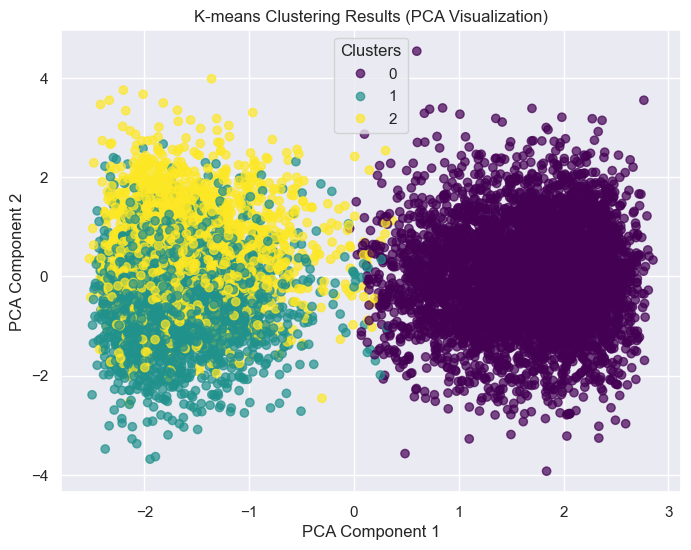

In [17]:
# Visualize clusters with PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title('K-means Clustering Results (PCA Visualization)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()